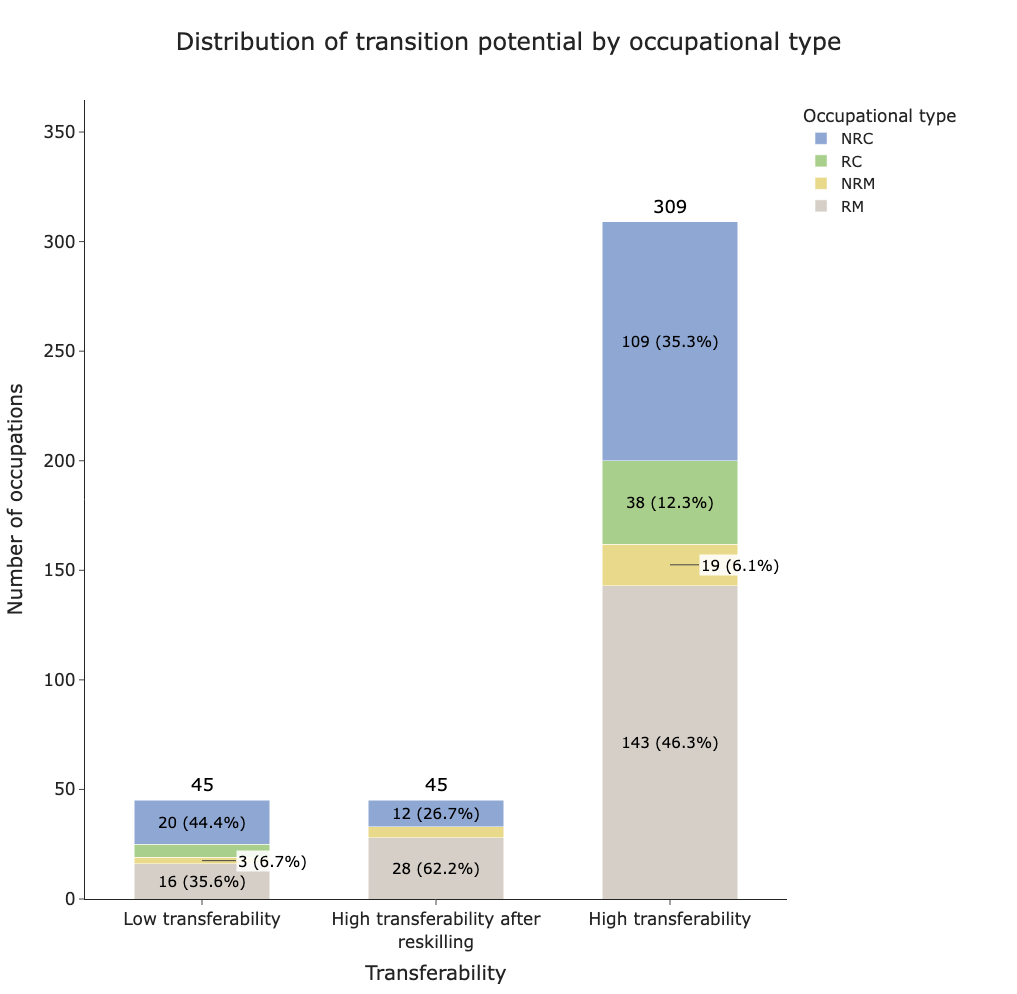

In [1]:
# Fig 2B picture drawing
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

# =========================
# 1. Load data
# =========================
df = pd.read_excel(
    "Your path/Stranded_Occupations_Replication/Data/use/simocc885&851_uq.xlsx"
)

# =========================
# 2. Map transferability
# =========================
transfer_map = {
    0: "Low transferability",
    1: "High transferability after reskilling",
    2: "High transferability"
}
df["Transferability"] = df["simocc_885_uq"].map(transfer_map)

# =========================
# 3. Process skill type
# =========================
skill_cols = ["nrm", "rm", "nrc", "rc"]
for col in skill_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["Skill Type"] = df[skill_cols].idxmax(axis=1)

skill_map = {
    "nrc": "NRC",
    "rc": "RC",
    "nrm": "NRM",
    "rm": "RM"
}
df["Skill Type"] = df["Skill Type"].map(skill_map)

# =========================
# 4. Aggregate statistics
# =========================
transfer_order = [
    "Low transferability",
    "High transferability after reskilling",
    "High transferability"
]

x_labels = [
    "Low transferability",
    "High transferability after<br>reskilling",
    "High transferability"
]

skill_order = ["RM","NRM","RC","NRC" ]

count_df = (
    df.groupby(["Transferability", "Skill Type"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=transfer_order, columns=skill_order, fill_value=0)
)

totals = count_df.sum(axis=1)
share_df = count_df.div(totals, axis=0).fillna(0)

# =========================
# 5. Color settings
# =========================
color_map = {
    "NRC": "#8EA7D3",   # blue
    "RC":  "#A8CF8B",   # green
    "NRM": "#E9D98B",   # yellow
    "RM":  "#D6CFC7"    # gray-purple
}

# =========================
# 6. Draw stacked bar chart
# =========================
fig = go.Figure()

small_threshold = 0.07
count_threshold = 5
fixed_font_size = 15

for skill in skill_order:
    counts = count_df[skill].tolist()
    shares = share_df[skill].tolist()

    text_labels = []
    for c, s in zip(counts, shares):
        if c > 0 and s >= small_threshold and c >= count_threshold:
            text_labels.append(f"{c} ({s*100:.1f}%)")
        else:
            text_labels.append("")

    fig.add_trace(go.Bar(
        x=x_labels,
        y=counts,
        name=skill,
        marker_color=color_map[skill],
        width=0.58,
        text=text_labels,
        textposition="inside",
        textfont=dict(size=fixed_font_size, color="black"),
        insidetextanchor="middle",
        cliponaxis=False,
        customdata=shares,
        hovertemplate=(
            f"<b>{skill}</b><br>"
            "Transferability: %{x}<br>"
            "Count: %{y}<br>"
            "Share within group: %{customdata:.1%}<br>"
            "<extra></extra>"
        )
    ))

# =========================
# 7. Total count on top
# =========================
for x, total in zip(x_labels, totals):
    fig.add_annotation(
        x=x,
        y=total,
        text=str(int(total)),
        showarrow=False,
        yshift=16,
        font=dict(size=18, color="black")
    )

# =========================
# 8. External labels for small segments
# =========================
cum_df = count_df.cumsum(axis=1)

for i, transfer in enumerate(transfer_order):
    x = x_labels[i]

    for skill in skill_order:
        c = count_df.loc[transfer, skill]
        s = share_df.loc[transfer, skill]

        if c == 0:
            continue

        y_top = cum_df.loc[transfer, skill]
        y_bottom = y_top - c
        y_mid = (y_top + y_bottom) / 2

        if s < small_threshold or c < count_threshold:
            fig.add_annotation(
                x=x,
                y=y_mid,
                text=f"{c} ({s*100:.1f}%)",
                showarrow=True,
                arrowhead=0,
                ax=70,
                ay=0,
                font=dict(size=fixed_font_size, color="black"),
                bgcolor="rgba(255,255,255,0.88)",
                bordercolor="rgba(0,0,0,0)"
            )

# =========================
# 9. Beautify the figure
# =========================
fig.update_layout(
    barmode="stack",
    template="simple_white",
    width=1150,
    height=980,
    bargap=0.30,
    uniformtext=dict(
        minsize=fixed_font_size,
        mode="hide"
    ),
    title=dict(
        text="Distribution of transition potential by occupational type",
        x=0.5,
        xanchor="center",
        font=dict(size=24)
    ),
    xaxis=dict(
        title="Transferability",
        title_font=dict(size=20),
        tickfont=dict(size=17)
    ),
    yaxis=dict(
        title="Number of occupations",
        title_font=dict(size=20),
        tickfont=dict(size=17),
        range=[0, max(totals) * 1.18]
    ),
    legend=dict(
        title="Occupational type",
        title_font=dict(size=17),
        font=dict(size=15),
        orientation="v",
        x=1.02,
        y=1
    ),
    margin=dict(t=100, l=85, r=230, b=95)
)

fig.show()

# Export
pio.write_image(
    fig,
    "Your path/Stranded_Occupations_Replication/Data/temp/fig2b.svg"
)



各组真实就业人数：
type_skill_all       RM    NRM      RC     NRC
Transferability                               
Low                81.6    0.9    46.4   171.1
HTAR              301.5    8.6     0.0    58.9
HT               3192.6  203.0  2849.2  1238.2

各组组内占比（%）：
type_skill_all      RM   NRM     RC    NRC
Transferability                           
Low              27.20  0.30  15.47  57.03
HTAR             81.71  2.33   0.00  15.96
HT               42.66  2.71  38.08  16.55


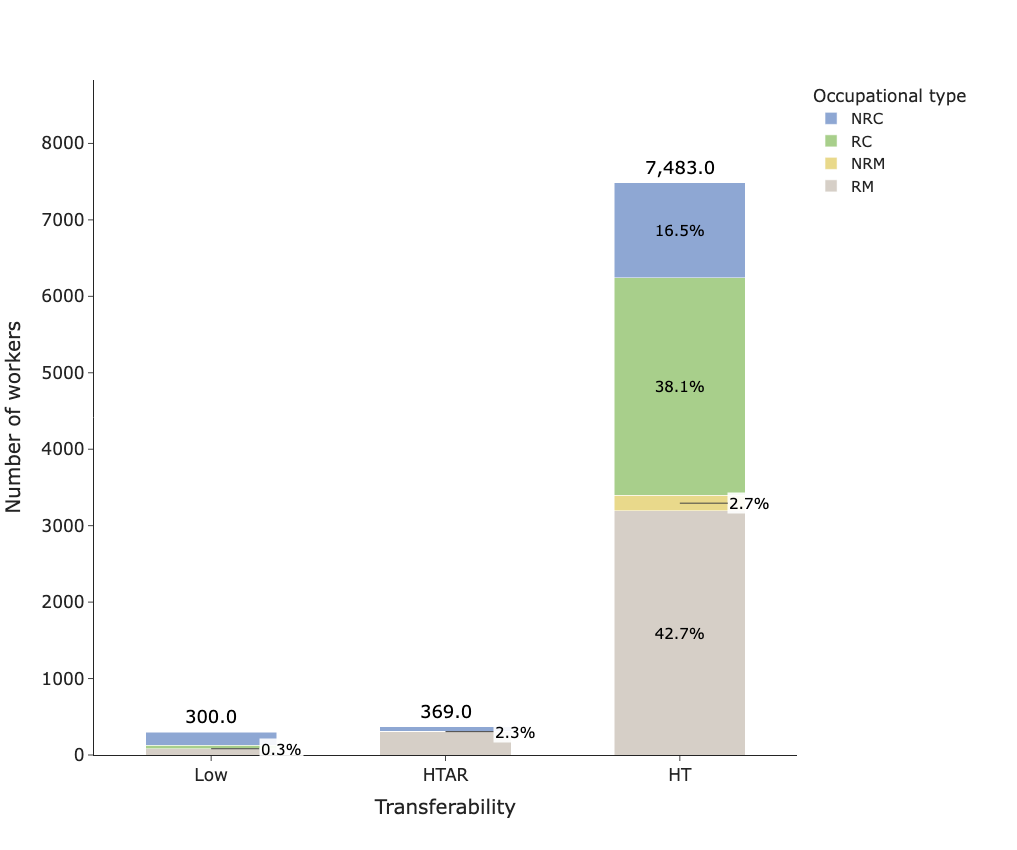


文件已导出：
/Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/Supplementary Figure 3.svg
/Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/Supplementary Figure 3.png


In [2]:
# Supplementary Figure 3 picture drawing
"""
Description:
1. Load naics_nem_new.dta (actual employment figures)
2. Load simocc885&851_uq.xlsx (Transferability grouping)
3. Merge on occupation_code
4. Filter for strand_ind == 1 (stranded industries)
5. Keep only the three groups: Low / HTAR / HT
6. Keep only the four occupation types: RM / NRM / RC / NRC
7. Compute within-group share based on actual Employment
8. Draw a fig2b-style stacked bar chart
9. Export SVG and PNG
"""

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from pathlib import Path

# =========================
# 1. File paths
# =========================
naics_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/naics_nem_new.dta")
uq_path = Path("Your path/Stranded_Occupations_Replication/Data/use/simocc885&851_uq.xlsx")

out_svg = Path("Your path/Stranded_Occupations_Replication/Data/temp/Supplementary Figure 3.svg")
out_png = Path("Your path/Stranded_Occupations_Replication/Data/temp/Supplementary Figure 3.png")

# =========================
# 2. Load data
# =========================
df = pd.read_stata(naics_path)
uq = pd.read_excel(uq_path)

df.columns = [c.strip() for c in df.columns]
uq.columns = [c.strip() for c in uq.columns]

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

for col in uq.select_dtypes(include="object").columns:
    uq[col] = uq[col].astype(str).str.strip()

# =========================
# 3. Standardize occupation code format
# =========================
def normalize_occ(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    if x == "" or x.lower() in {"nan", "none"}:
        return pd.NA
    if x.endswith(".0"):
        x = x[:-2]
    x = x.replace("-", "").replace(" ", "")
    if x.isdigit():
        x = x.zfill(6)
    return x

df["occ_std"] = df["occupation_code"].apply(normalize_occ)
uq["occ_std"] = uq["occupation_code"].apply(normalize_occ)

# =========================
# 4. Map Transferability
# =========================
transfer_map = {
    0: "Low",
    1: "HTAR",
    2: "HT"
}
uq["simocc_885_uq"] = pd.to_numeric(uq["simocc_885_uq"], errors="coerce")
uq["Transferability"] = uq["simocc_885_uq"].map(transfer_map)

uq_use = uq[["occ_std", "Transferability"]].dropna().drop_duplicates(subset=["occ_std"])

# =========================
# 5. Merge
# =========================
df = df.merge(uq_use, on="occ_std", how="left")

# =========================
# 6. Clean and filter
# =========================
df["Employment"] = pd.to_numeric(df["Employment"], errors="coerce")
df["strand_ind"] = pd.to_numeric(df["strand_ind"], errors="coerce")
df["type_skill_all"] = df["type_skill_all"].astype(str).str.strip()

skill_map = {
    "Routine Manual": "RM",
    "Non-Routine Manual": "NRM",
    "Routine Cognitive": "RC",
    "Non-Routine Cognitive": "NRC"
}

skill_order_full = [
    "Routine Manual",
    "Non-Routine Manual",
    "Routine Cognitive",
    "Non-Routine Cognitive"
]

skill_order_abbr = ["RM", "NRM", "RC", "NRC"]
transfer_order = ["Low", "HTAR", "HT"]

df = df[
    (df["strand_ind"] == 1) &
    (df["Transferability"].isin(transfer_order)) &
    (df["type_skill_all"].isin(skill_order_full)) &
    (df["Employment"].notna())
].copy()

# =========================
# 7. Aggregate actual employment
# =========================
emp_df = (
    df.groupby(["Transferability", "type_skill_all"], as_index=False)["Employment"]
      .sum()
)

# Pivot to wide format and fill missing combinations
emp_wide = (
    emp_df.pivot(index="Transferability", columns="type_skill_all", values="Employment")
          .reindex(index=transfer_order, columns=skill_order_full)
          .fillna(0)
)

# Total employment within each group
totals = emp_wide.sum(axis=1)

# Within-group share
share_wide = emp_wide.div(totals, axis=0).fillna(0)

# Rename columns to abbreviations
count_df = emp_wide.rename(columns=skill_map).reindex(columns=skill_order_abbr)
share_df = share_wide.rename(columns=skill_map).reindex(columns=skill_order_abbr)

print("\nActual employment by group:")
print(count_df.round(2))

print("\nWithin-group share (%) by group:")
print((share_df * 100).round(2))

# =========================
# 8. Draw figure
# =========================
color_map = {
    "RM":  "#D6CFC7",
    "NRM": "#E9D98B",
    "RC":  "#A8CF8B",
    "NRC": "#8EA7D3"
}

fig = go.Figure()

small_threshold = 0.06
fixed_font_size = 15

for skill in skill_order_abbr:
    counts = count_df[skill].tolist()
    shares = share_df[skill].tolist()

    text_labels = []
    for c, s in zip(counts, shares):
        if c > 0 and s >= small_threshold:
            text_labels.append(f"{s*100:.1f}%")
        else:
            text_labels.append("")

    fig.add_trace(go.Bar(
        x=transfer_order,
        y=counts,
        name=skill,
        marker_color=color_map[skill],
        width=0.56,
        text=text_labels,
        textposition="inside",
        textfont=dict(size=fixed_font_size, color="black"),
        insidetextanchor="middle",
        cliponaxis=False,
        customdata=shares,
        hovertemplate=(
            f"<b>{skill}</b><br>"
            "Group: %{x}<br>"
            "Employment: %{y:,.1f}<br>"
            "Share within group: %{customdata:.1%}<br>"
            "<extra></extra>"
        )
    ))

# Add total employment on top of each bar
for x, total in zip(transfer_order, totals.tolist()):
    fig.add_annotation(
        x=x,
        y=total,
        text=f"{total:,.1f}",
        showarrow=False,
        yshift=16,
        font=dict(size=18, color="black")
    )

# Place labels outside for small segments
cum_df = count_df.cumsum(axis=1)

for group in transfer_order:
    for skill in skill_order_abbr:
        c = count_df.loc[group, skill]
        s = share_df.loc[group, skill]

        if c == 0:
            continue

        y_top = cum_df.loc[group, skill]
        y_bottom = y_top - c
        y_mid = (y_top + y_bottom) / 2

        if s < small_threshold:
            fig.add_annotation(
                x=group,
                y=y_mid,
                text=f"{s*100:.1f}%",
                showarrow=True,
                arrowhead=0,
                ax=70,
                ay=0,
                font=dict(size=fixed_font_size, color="black"),
                bgcolor="rgba(255,255,255,0.90)",
                bordercolor="rgba(0,0,0,0)"
            )

# =========================
# 9. Beautify the figure
# =========================
fig.update_layout(
    barmode="stack",
    template="simple_white",
    width=950,
    height=850,
    bargap=0.32,
    uniformtext=dict(minsize=fixed_font_size, mode="hide"),
    xaxis=dict(
        title="Transferability",
        title_font=dict(size=20),
        tickfont=dict(size=17)
    ),
    yaxis=dict(
        title="Number of workers",
        title_font=dict(size=20),
        tickfont=dict(size=17),
        range=[0, max(totals) * 1.18]
    ),
    legend=dict(
        title="Occupational type",
        title_font=dict(size=17),
        font=dict(size=15),
        orientation="v",
        x=1.02,
        y=1
    ),
    margin=dict(t=80, l=85, r=220, b=95)
)

fig.show()

# =========================
# 10. Export
# =========================
pio.write_image(fig, str(out_svg))
pio.write_image(fig, str(out_png), scale=3)

print("\nFiles exported:")
print(out_svg)
print(out_png)

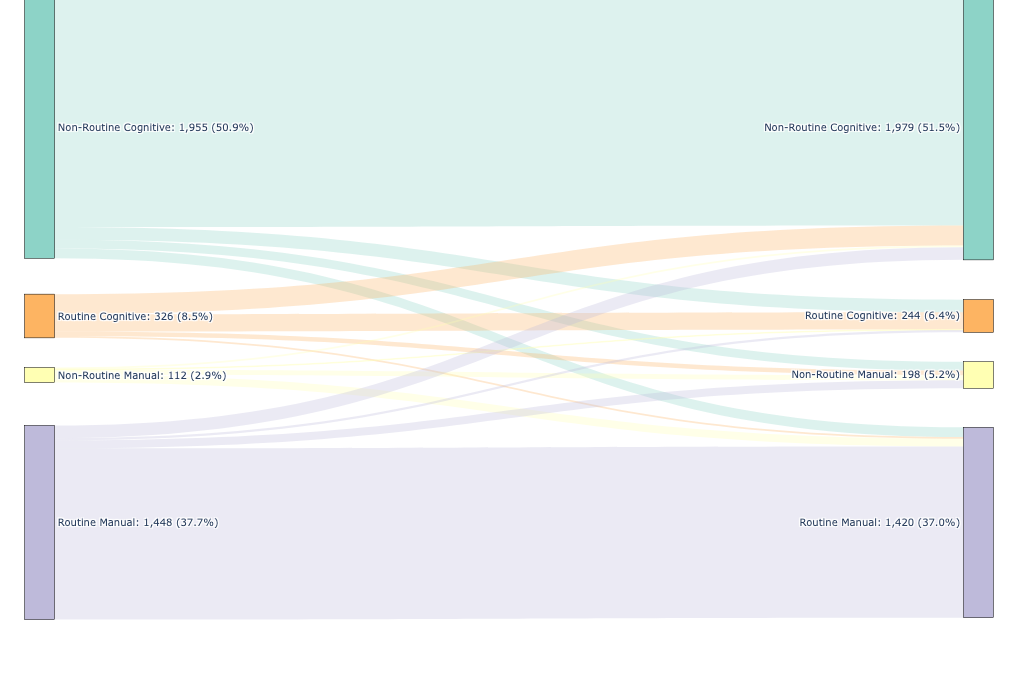

SVG 已导出到: /Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/fig2cl.svg


In [3]:
# Fig 2C left picture drawing
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

# =========================
# 1. Raw data
# =========================
data = {
    "type_skill_all": ["Non-Routine Cognitive"]*4 + ["Routine Cognitive"]*4 + ["Non-Routine Manual"]*4 
                     + ["Routine Manual"]*4,
    "match_type_skill": ["Non-Routine Cognitive", "Routine Cognitive", 
                         "Non-Routine Manual", "Routine Manual"]*4,
    "k": [1722, 94, 66, 73,
          150, 128, 35, 13,
          12, 5, 38, 57,
          95, 17, 59, 1277]
}

df = pd.DataFrame(data)
total = df["k"].sum()

# =========================
# 2. Fixed order: NRC → RC → NRM → RM
# =========================
skill_order = [
    "Non-Routine Cognitive",   # NRC
    "Routine Cognitive",       # RC
    "Non-Routine Manual",      # NRM
    "Routine Manual"           # RM
]

# =========================
# 3. Compute left/right totals and reorder by fixed sequence
# =========================
left_totals = (
    df.groupby("type_skill_all")["k"]
    .sum()
    .reindex(skill_order)
)

right_totals = (
    df.groupby("match_type_skill")["k"]
    .sum()
    .reindex(skill_order)
)

# =========================
# 4. Color settings
# =========================
color_settings = {
    "Non-Routine Cognitive": {"node": "#8dd3c7", "link": "rgba(141, 211, 199, 0.3)"},
    "Routine Cognitive": {"node": "#fdb462", "link": "rgba(253, 180, 98, 0.3)"},
    "Non-Routine Manual": {"node": "#ffffb3", "link": "rgba(255, 255, 179, 0.3)"},
    "Routine Manual": {"node": "#bebada", "link": "rgba(190, 186, 218, 0.3)"}
}

# =========================
# 5. Left and right node indices
# =========================
left_index = {cat: i for i, cat in enumerate(skill_order)}
right_index = {cat: i + 4 for i, cat in enumerate(skill_order)}

# =========================
# 6. Manually fix node positions
#    Smaller y = higher position
# =========================
y_positions = [0.08, 0.4, 0.5, 0.75]

node_x = [0.01]*4 + [0.99]*4
node_y = y_positions + y_positions

# =========================
# 7. Generate Sankey diagram
# =========================
fig = go.Figure(go.Sankey(
    arrangement="fixed",   # Key: fix node positions
    node=dict(
        pad=25,
        thickness=30,
        line=dict(color="black", width=0.5),
        label=[
            *[f"{cat}: {left_totals[cat]:,} ({left_totals[cat]/total:.1%})" for cat in skill_order],
            *[f"{cat}: {right_totals[cat]:,} ({right_totals[cat]/total:.1%})" for cat in skill_order]
        ],
        color=[color_settings[cat]["node"] for cat in skill_order] +
              [color_settings[cat]["node"] for cat in skill_order],
        x=node_x,
        y=node_y
    ),
    link=dict(
        source=[left_index[src] for src in df["type_skill_all"]],
        target=[right_index[tar] for tar in df["match_type_skill"]],
        value=df["k"],
        color=[color_settings[src]["link"] for src in df["type_skill_all"]],
        customdata=df["k"] / total,
        hovertemplate="<b>%{source.label}</b> → <b>%{target.label}</b><br>" +
                      "Flow: %{value:,}<br>" +
                      "Path ratio: %{customdata:.1%}<extra></extra>"
    )
))

# =========================
# 8. Layout beautification
# =========================
fig.update_layout(
    title_x=0.5,
    font=dict(size=10),
    width=1000,
    height=700,
    margin=dict(t=80, b=30, l=30, r=30)
)

fig.show()

# =========================
# 9. Export SVG
# =========================
out_svg = "Your path/Stranded_Occupations_Replication/Data/temp/fig2cl.svg"
fig.write_image(out_svg, format="svg")

print(f"SVG exported to: {out_svg}")

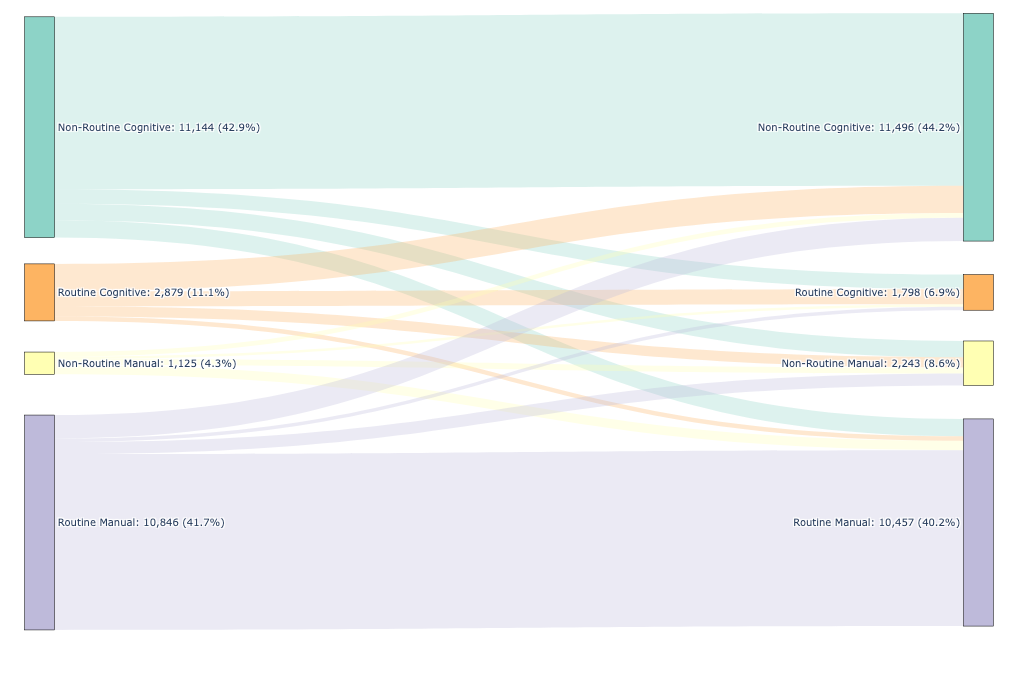

SVG 已导出到: /Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/fig2cl.svg


In [4]:
# Fig 2C right picture drawing
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

# =========================
# 1. Raw data
# =========================
data = {
    "type_skill_all": ["Non-Routine Cognitive"]*4 + ["Routine Cognitive"]*4 + ["Non-Routine Manual"]*4 
                     + ["Routine Manual"]*4,
    "match_type_skill": ["Non-Routine Cognitive", "Routine Cognitive", 
                         "Non-Routine Manual", "Routine Manual"]*4,
    "k": [8701, 740,823, 880,
          1382, 761, 512, 224,
          233, 116, 303, 473,
          1180, 181, 605, 8880]
}

df = pd.DataFrame(data)
total = df["k"].sum()

# =========================
# 2. Fixed order: NRC → RC → NRM → RM
# =========================
skill_order = [
    "Non-Routine Cognitive",   # NRC
    "Routine Cognitive",       # RC
    "Non-Routine Manual",      # NRM
    "Routine Manual"           # RM
]

# =========================
# 3. Compute left/right totals and reorder by fixed sequence
# =========================
left_totals = (
    df.groupby("type_skill_all")["k"]
    .sum()
    .reindex(skill_order)
)

right_totals = (
    df.groupby("match_type_skill")["k"]
    .sum()
    .reindex(skill_order)
)

# =========================
# 4. Color settings
# =========================
color_settings = {
    "Non-Routine Cognitive": {"node": "#8dd3c7", "link": "rgba(141, 211, 199, 0.3)"},
    "Routine Cognitive": {"node": "#fdb462", "link": "rgba(253, 180, 98, 0.3)"},
    "Non-Routine Manual": {"node": "#ffffb3", "link": "rgba(255, 255, 179, 0.3)"},
    "Routine Manual": {"node": "#bebada", "link": "rgba(190, 186, 218, 0.3)"}
}

# =========================
# 5. Left and right node indices
# =========================
left_index = {cat: i for i, cat in enumerate(skill_order)}
right_index = {cat: i + 4 for i, cat in enumerate(skill_order)}

# =========================
# 6. Manually fix node positions
#    Smaller y = higher position
# =========================
y_positions = [0.08, 0.36, 0.48, 0.75]

node_x = [0.01]*4 + [0.99]*4
node_y = y_positions + y_positions

# =========================
# 7. Generate Sankey diagram
# =========================
fig = go.Figure(go.Sankey(
    arrangement="fixed",   # Key: fix node positions
    node=dict(
        pad=25,
        thickness=30,
        line=dict(color="black", width=0.5),
        label=[
            *[f"{cat}: {left_totals[cat]:,} ({left_totals[cat]/total:.1%})" for cat in skill_order],
            *[f"{cat}: {right_totals[cat]:,} ({right_totals[cat]/total:.1%})" for cat in skill_order]
        ],
        color=[color_settings[cat]["node"] for cat in skill_order] +
              [color_settings[cat]["node"] for cat in skill_order],
        x=node_x,
        y=node_y
    ),
    link=dict(
        source=[left_index[src] for src in df["type_skill_all"]],
        target=[right_index[tar] for tar in df["match_type_skill"]],
        value=df["k"],
        color=[color_settings[src]["link"] for src in df["type_skill_all"]],
        customdata=df["k"] / total,
        hovertemplate="<b>%{source.label}</b> → <b>%{target.label}</b><br>" +
                      "Flow: %{value:,}<br>" +
                      "Path ratio: %{customdata:.1%}<extra></extra>"
    )
))

# =========================
# 8. Layout beautification
# =========================
fig.update_layout(
    title_x=0.5,
    font=dict(size=10),
    width=1000,
    height=700,
    margin=dict(t=80, b=30, l=30, r=30)
)

fig.show()

# =========================
# 9. Export SVG
# =========================
out_svg = "Your path/Stranded_Occupations_Replication/Data/temp/fig2cl.svg"
fig.write_image(out_svg, format="svg")

print(f"SVG exported to: {out_svg}")

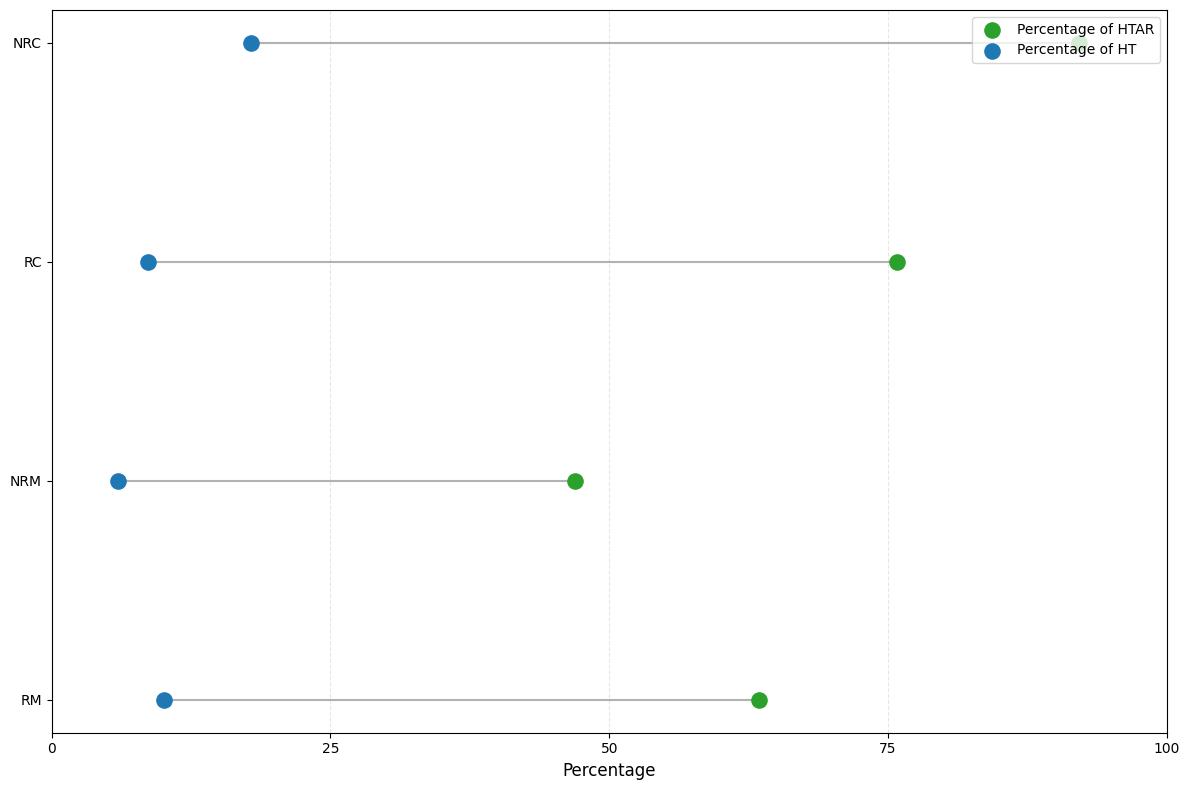

SVG 已导出到: /Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/fig2d.svg


In [5]:
# Fig 2D
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Data
# =========================
data = {
    'Sch': ['NRC', 'RC', 'NRM', 'RM'],
    'Similarity ≥ 0.85': [17.9, 8.6, 5.9, 10.1],
    'Similarity ≥ 0.8': [92.1, 75.8, 46.9, 63.4]
}

df = pd.DataFrame(data)

# =========================
# 2. Fixed order: NRC > RC > NRM > RM
# =========================
custom_order = ['NRC', 'RC', 'NRM', 'RM']
df['Sch'] = pd.Categorical(df['Sch'], categories=custom_order, ordered=True)
df = df.sort_values('Sch')

# =========================
# 3. Draw dumbbell plot
# =========================
fig, ax = plt.subplots(figsize=(12, 8))

# Connecting lines
for _, row in df.iterrows():
    ax.plot(
        [row['Similarity ≥ 0.8'], row['Similarity ≥ 0.85']],
        [row['Sch'], row['Sch']],
        color='grey',
        linewidth=1.5,
        alpha=0.6
    )

# Two groups of dots
ax.scatter(
    df['Similarity ≥ 0.8'], df['Sch'],
    color='#2ca02c', s=120,
    label='Percentage of HTAR',
    zorder=3
)

ax.scatter(
    df['Similarity ≥ 0.85'], df['Sch'],
    color='#1f77b4', s=120,
    label='Percentage of HT',
    zorder=3
)

# =========================
# 4. Axes and style
# =========================
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0', '25', '50', '75', '100'])

# Keep NRC at the top
ax.invert_yaxis()

ax.legend(loc='upper right', frameon=True)
ax.grid(axis='x', linestyle='--', alpha=0.3)

ax.set_xlabel('Percentage', fontsize=12)

plt.tight_layout()

# =========================
# 5. Export SVG
# =========================
out_svg = "Your path/Stranded_Occupations_Replication/Data/temp/fig2d.svg"
plt.savefig(out_svg, format="svg", bbox_inches="tight")

plt.show()

print(f"SVG exported to: {out_svg}")
